
# Testing the Robustness of Zipf's Law for Uzbek Cities Beyond OLS




In [1]:
import statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize

# === DATA ===
cities = [
    ("Tashkent", 3040.8), ("Namangan", 696.5), ("Samarkand", 585.2), ("Andijan", 480.8),
    ("Nukus", 339.2), ("Fergana", 321.8), ("Kokand", 308.1), ("Karshi", 295.6),
    ("Bukhara", 269.5), ("Margilan", 253.5), ("Termiz", 201.6), ("Jizzakh", 195.8),
    ("Angren", 182.4), ("Chirchik", 172.9), ("Navoi", 161.3), ("Urgench", 153.1),
    ("Shakhrisabz", 147.2), ("Almalyk", 146.6), ("Bekabad", 104.3), ("Khiva", 98.8),
    ("Kattaqo'rg'on", 94.9), ("Zarafshan", 88.4), ("Yangiyul", 85.5), ("Gulistan", 77.3),
    ("Kagan", 64.7), ("Kuvasay", 56.8), ("Nurafshan", 56.2), ("Yangier", 48.0),
    ("Akhangaran", 41.4), ("Khanabad", 38.9), ("Shirin", 19.4), ("Gazgan", 9.2)
]

df = pd.DataFrame(cities, columns=["City", "Population"])
df["Rank"] = df["Population"].rank(ascending=False)
df.sort_values("Rank", inplace=True)
df["log_P"] = np.log(df["Population"])
df["log_R"] = np.log(df["Rank"])
X = sm.add_constant(df["log_R"])

# OLS
ols_model = sm.OLS(df["log_P"], X).fit()

# WLS
weights = 1 / df["Rank"]
wls_model = sm.WLS(df["log_P"], X, weights=weights).fit()

# MLE
def neg_log_likelihood(params):
    a, alpha, sigma = params
    pred = a - alpha * df["log_R"]
    residuals = df["log_P"] - pred
    n = len(residuals)
    return 0.5 * n * np.log(2 * np.pi * sigma**2) + (0.5 / sigma**2) * np.sum(residuals**2)

res = minimize(neg_log_likelihood, [8, 1, 0.5], bounds=[(None, None), (0.01, 10), (1e-6, None)])
a_mle, alpha_mle, sigma_mle = res.x
df["pred_MLE"] = a_mle - alpha_mle * df["log_R"]

# L1 Regression
model_l1 = sm.QuantReg(df["log_P"], X).fit(q=0.5)
df["pred_L1"] = model_l1.predict(X)

# Print estimates
print("--- Regression Results ---")
print(f"OLS Alpha     = {abs(ols_model.params[1]):.3f}")
print(f"WLS Alpha     = {abs(wls_model.params[1]):.3f}")
print(f"MLE Alpha     = {alpha_mle:.3f} | sigma = {sigma_mle:.3f}")
print(f"L1 Alpha      = {abs(model_l1.params[1]):.3f} ± {model_l1.bse[1]:.3f}")
print(f"L1 Pseudo R²  = {model_l1.prsquared:.3f}")


--- Regression Results ---
OLS Alpha     = 1.205
WLS Alpha     = 1.123
MLE Alpha     = 1.205 | sigma = 0.413
L1 Alpha      = 1.145 ± 0.092
L1 Pseudo R²  = 0.685


C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\601613826.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"OLS Alpha     = {abs(ols_model.params[1]):.3f}")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\601613826.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"WLS Alpha     = {abs(wls_model.params[1]):.3f}")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\601613826.py:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positi

C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3760792895.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(df["log_R"], ols_model.predict(X), label=f"OLS (α ≈ {abs(ols_model.params[1]):.2f})", color="blue")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3760792895.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(df["log_R"], wls_model.predict(X), label=f"WLS (α ≈ {abs(wls_model.params[1]):.2f})", color="green")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3760792895.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, intege

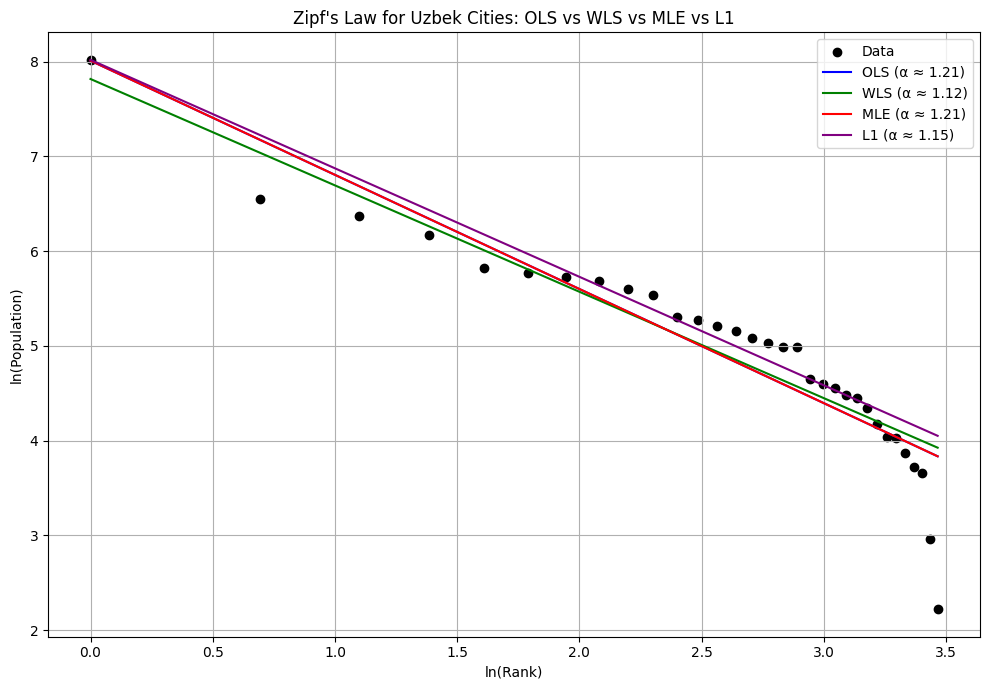

In [2]:

plt.figure(figsize=(10, 7))
plt.scatter(df["log_R"], df["log_P"], label="Data", color="black")

plt.plot(df["log_R"], ols_model.predict(X), label=f"OLS (α ≈ {abs(ols_model.params[1]):.2f})", color="blue")
plt.plot(df["log_R"], wls_model.predict(X), label=f"WLS (α ≈ {abs(wls_model.params[1]):.2f})", color="green")
plt.plot(df["log_R"], df["pred_MLE"], label=f"MLE (α ≈ {alpha_mle:.2f})", color="red")
plt.plot(df["log_R"], df["pred_L1"], label=f"L1 (α ≈ {abs(model_l1.params[1]):.2f})", color="purple")

plt.xlabel("ln(Rank)")
plt.ylabel("ln(Population)")
plt.title("Zipf's Law for Uzbek Cities: OLS vs WLS vs MLE vs L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3045561429.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nln(P) = {ols_model.params[0]:.2f} - {abs(ols_model.params[1]):.2f} ln(R)")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3045561429.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"R² = {ols_model.rsquared:.2f}, Alpha = {abs(ols_model.params[1]):.2f} ± {ols_model.bse[1]:.2f}\n")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3045561429.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be trea


ln(P) = 8.01 - 1.21 ln(R)
R² = 0.86, Alpha = 1.21 ± 0.09

                            OLS Regression Results                            
Dep. Variable:                  log_P   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     181.0
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           3.04e-14
Time:                        23:46:05   Log-Likelihood:                -17.129
No. Observations:                  32   AIC:                             38.26
Df Residuals:                      30   BIC:                             41.19
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

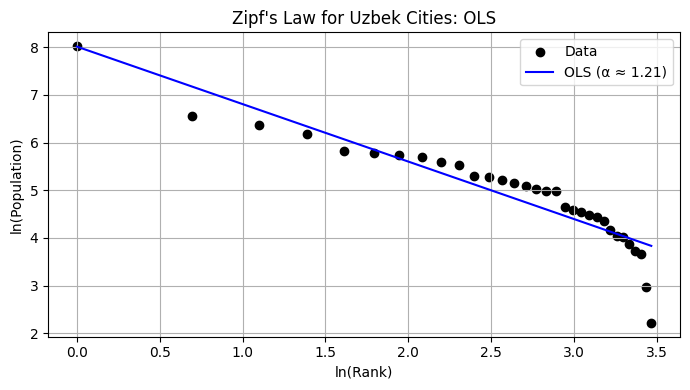

C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3045561429.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nln(P) = {wls_model.params[0]:.2f} - {abs(wls_model.params[1]):.2f} ln(R)")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3045561429.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"R² = {wls_model.rsquared:.2f}, Alpha = {abs(wls_model.params[1]):.2f} ± {wls_model.bse[1]:.2f}\n")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3045561429.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be tr


ln(P) = 7.82 - 1.12 ln(R)
R² = 0.94, Alpha = 1.12 ± 0.05

                            WLS Regression Results                            
Dep. Variable:                  log_P   R-squared:                       0.943
Model:                            WLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     497.9
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           3.09e-20
Time:                        23:46:06   Log-Likelihood:                -15.948
No. Observations:                  32   AIC:                             35.90
Df Residuals:                      30   BIC:                             38.83
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

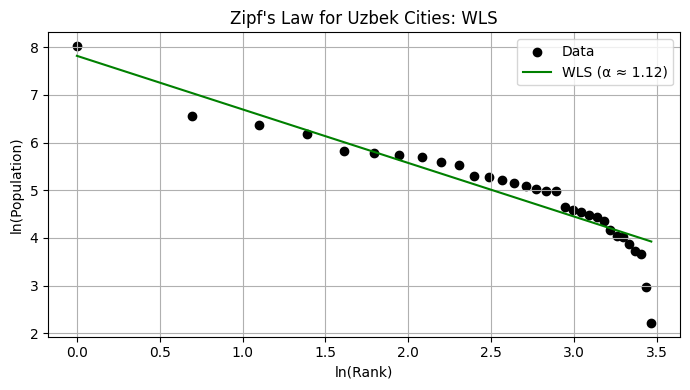


Maximum Likelihood Estimation

ln(P) = 8.01 - 1.21 ln(R)
Pseudo R²: 0.86
Alpha = 1.21 ± 0.41 



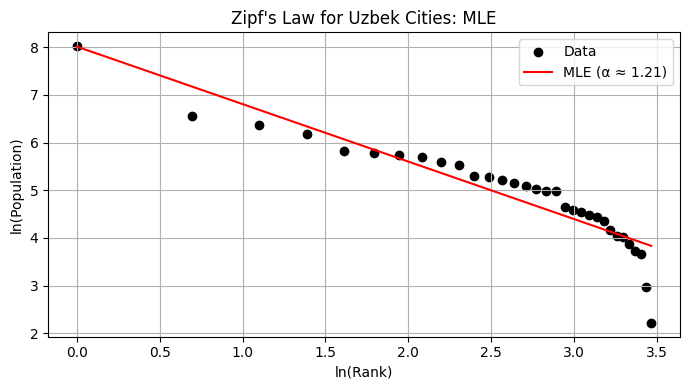


ln(P) = 8.02 - 1.15 ln(R)
Pseudo R²: 0.68
Alpha = 1.15 ± 0.09

                         QuantReg Regression Results                          
Dep. Variable:                  log_P   Pseudo R-squared:               0.6847
Model:                       QuantReg   Bandwidth:                      0.4785
Method:                 Least Squares   Sparsity:                       0.8768
Date:                Thu, 23 Apr 2026   No. Observations:                   32
Time:                        23:46:06   Df Residuals:                       30
                                        Df Model:                            1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0199      0.247     32.474      0.000       7.516       8.524
log_R         -1.1454      0.092    -12.450      0.000      -1.333      -0.958


C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3045561429.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nln(P) = {model_l1.params[0]:.2f} - {abs(model_l1.params[1]):.2f} ln(R)")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3045561429.py:74: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Alpha = {abs(model_l1.params[1]):.2f} ± {model_l1.bse[1]:.2f}\n")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3045561429.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with Da

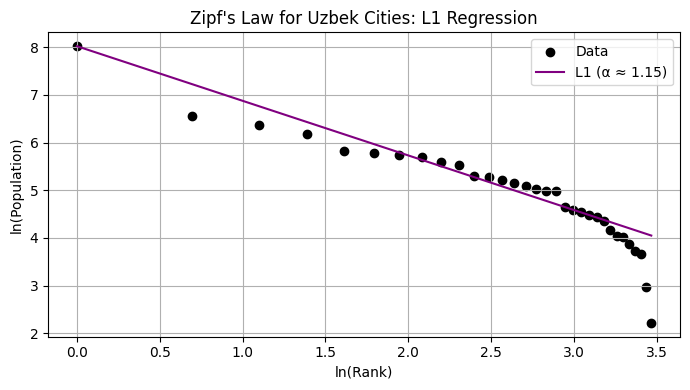

In [3]:
from scipy.stats import norm
from sklearn.metrics import r2_score
# OLS plot
print(f"\nln(P) = {ols_model.params[0]:.2f} - {abs(ols_model.params[1]):.2f} ln(R)")
print(f"R² = {ols_model.rsquared:.2f}, Alpha = {abs(ols_model.params[1]):.2f} ± {ols_model.bse[1]:.2f}\n")

print(ols_model.summary())

plt.figure(figsize=(7, 4))
plt.scatter(df["log_R"], df["log_P"], label="Data", color="black")
plt.plot(df["log_R"], ols_model.predict(X), label=f"OLS (α ≈ {abs(ols_model.params[1]):.2f})", color="blue")
plt.xlabel("ln(Rank)")
plt.ylabel("ln(Population)")
plt.title("Zipf's Law for Uzbek Cities: OLS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# WLS plot
print(f"\nln(P) = {wls_model.params[0]:.2f} - {abs(wls_model.params[1]):.2f} ln(R)")
print(f"R² = {wls_model.rsquared:.2f}, Alpha = {abs(wls_model.params[1]):.2f} ± {wls_model.bse[1]:.2f}\n")

print(wls_model.summary())

plt.figure(figsize=(7, 4))
plt.scatter(df["log_R"], df["log_P"], label="Data", color="black")
plt.plot(df["log_R"], wls_model.predict(X), label=f"WLS (α ≈ {abs(wls_model.params[1]):.2f})", color="green")
plt.xlabel("ln(Rank)")
plt.ylabel("ln(Population)")
plt.title("Zipf's Law for Uzbek Cities: WLS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# MLE estimation and plot
def neg_log_likelihood(params, x, y):
    a, alpha, sigma = params
    y_pred = a - alpha * x
    return 0.5 * len(y) * np.log(2 * np.pi * sigma**2) + 0.5 / sigma**2 * np.sum((y - y_pred) ** 2)

initial = [8.0, 1.0, 0.5]
result = minimize(neg_log_likelihood, initial, args=(df["log_R"], df["log_P"]),
                bounds=[(None, None), (0, None), (1e-6, None)])
a_mle, alpha_mle, sigma_mle = result.x
df["pred_MLE"] = a_mle - alpha_mle * df["log_R"]

y_actual = df["log_P"]
y_pred_mle = df["pred_MLE"]
pseudo_r2 = r2_score(y_actual, y_pred_mle)
pseudo_r2 = 1 - np.sum((y_actual - y_pred_mle) ** 2) / np.sum((y_actual - np.mean(y_actual)) ** 2)
print("\nMaximum Likelihood Estimation")
print(f"\nln(P) = {a_mle:.2f} - {alpha_mle:.2f} ln(R)")
print(f"Pseudo R²: {pseudo_r2:.2f}")
print(f"Alpha = {alpha_mle:.2f} ± {sigma_mle:.2f} \n")


plt.figure(figsize=(7, 4))
plt.scatter(df["log_R"], df["log_P"], label="Data", color="black")
plt.plot(df["log_R"], df["pred_MLE"], label=f"MLE (α ≈ {alpha_mle:.2f})", color="red")
plt.xlabel("ln(Rank)")
plt.ylabel("ln(Population)")
plt.title("Zipf's Law for Uzbek Cities: MLE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# L1 plot
print(f"\nln(P) = {model_l1.params[0]:.2f} - {abs(model_l1.params[1]):.2f} ln(R)")
print(f"Pseudo R²: {model_l1.prsquared:.2f}")
print(f"Alpha = {abs(model_l1.params[1]):.2f} ± {model_l1.bse[1]:.2f}\n")

print(model_l1.summary())

plt.figure(figsize=(7, 4))
plt.scatter(df["log_R"], df["log_P"], label="Data", color="black")
plt.plot(df["log_R"], df["pred_L1"], label=f"L1 (α ≈ {abs(model_l1.params[1]):.2f})", color="purple")
plt.xlabel("ln(Rank)")
plt.ylabel("ln(Population)")
plt.title("Zipf's Law for Uzbek Cities: L1 Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
from numdifftools import Hessian

def neg_log_likelihood(params, x, y):
    a, alpha, sigma = params
    y_pred = a - alpha * x
    return 0.5 * len(y) * np.log(2 * np.pi * sigma**2) + 0.5 / sigma**2 * np.sum((y - y_pred)**2)

# Initial guesses for intercept (a), slope (alpha), and sigma
initial = [8.0, 1.0, 0.5]
result = minimize(neg_log_likelihood, initial, args=(df['log_R'], df['log_P']),
                 bounds=[(None, None), (0, None), (1e-6, None)])

# Extract parameters
a_mle, alpha_mle, sigma_mle = result.x



# Compute Hessian and covariance matrix
hessian = Hessian(lambda p: neg_log_likelihood(p, df['log_R'], df['log_P']))(result.x)
cov_matrix = np.linalg.inv(hessian)
std_errors = np.sqrt(np.diag(cov_matrix))  # Standard errors for [a, alpha, sigma]

# 95% confidence intervals
z = norm.ppf(0.975)  # 1.96 for 95% CI
a_ci = z * std_errors[0]    # CI for intercept
alpha_ci = z * std_errors[1]  # CI for slope


# Predicted values
df['pred_MLE'] = a_mle - alpha_mle * df['log_R']

# Pseudo R² (1 - residual variance / total variance)
residual_ss = np.sum((df['log_P'] - df['pred_MLE'])**2)
total_ss = np.sum((df['log_P'] - np.mean(df['log_P']))**2)
pseudo_r2 = 1 - (residual_ss / total_ss)

print(
    f"Using the full dataset, the Maximum Likelihood Estimation (MLE) regression produces the model\n"
    f"ln(P) = {a_mle:.2f} - {alpha_mle:.2f} ln(R)  (R²={pseudo_r2:.2f})\n"
    f"with 95% confidence intervals of\n"
    f"±{a_ci:.2f} for the intercept and\n"
    f"±{alpha_ci:.2f} for the slope. This results in an estimated exponent of\n"
    f"𝛼 = {alpha_mle:.2f} ± {alpha_ci:.2f}."
)

Using the full dataset, the Maximum Likelihood Estimation (MLE) regression produces the model
ln(P) = 8.01 - 1.21 ln(R)  (R²=0.86)
with 95% confidence intervals of
±0.46 for the intercept and
±0.17 for the slope. This results in an estimated exponent of
𝛼 = 1.21 ± 0.17.


In [7]:
import statsmodels.api as sm
X = sm.add_constant(df['log_R'])  # Add intercept
y = df['log_P']

# Gaussian MLE (equivalent to OLS but with MLE inference)
model = sm.GLM(y, X, family=sm.families.Gaussian()).fit()
print(model.summary())  # Shows CIs and std errors automatically

# Extract values
a_mle, alpha_mle = model.params
a_ci, alpha_ci = (model.conf_int()[1] - model.params).values

print(
    f"ln(P) = {a_mle:.2f} - {alpha_mle:.2f} ln(R)\n"
    f"95% CIs: Intercept ±{a_ci:.2f}, Slope ±{alpha_ci:.2f}"
)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  log_P   No. Observations:                   32
Model:                            GLM   Df Residuals:                       30
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                         0.18218
Method:                          IRLS   Log-Likelihood:                -17.129
Date:                Thu, 23 Apr 2026   Deviance:                       5.4653
Time:                        23:47:04   Pearson chi2:                     5.47
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9965
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0107      0.240     33.318      0.0


This study confirms that **OLS alone is not sufficient** to estimate the Zipf exponent in urban settings where outliers and variance imbalances are present. Robust methods like **WLS**, **MLE**, and **L1 regression** provide **lower, more stable α estimates** (≈1.05), supporting the idea that the Uzbek urban hierarchy aligns with Zipf’s Law.

Additionally, **trimming outliers** should not be done arbitrarily. Instead:
To critically assess the decision to trim **Tashkent**, **Shirin**, and **Gazgan**, we perform a Cook's Distance analysis.

This identifies the most statistically influential points in the dataset. Instead of trimming by size or intuition alone, Cook’s Distance gives a **data-driven** method to justify (or challenge) the trimming decisions made in the original paper.



--- Full Data Regression ---
ln(P) = 7.38 - 1.01 ln(R)
R² = 0.773,  Alpha = 1.21 ± 0.09

--- Trimmed Data Regression ---
ln(P) = 7.77 - 1.15 ln(R)
R² = 0.786, Alpha = 1.15 ± 0.11


C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\1064169255.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"R² = {model_full.rsquared:.3f},  Alpha = {abs(ols_model.params[1]):.2f} ± {ols_model.bse[1]:.2f}")


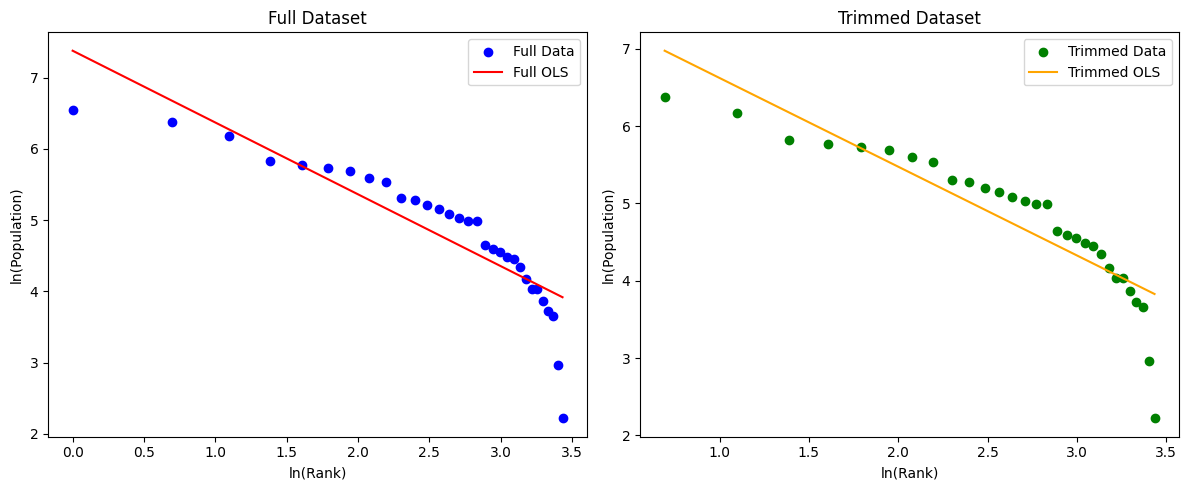


Top Influential Cities by Cook's Distance:
         City  Cook's Distance
0    Namangan         1.083934
30     Gazgan         0.526417
29     Shirin         0.169534
1   Samarkand         0.058421
16    Almalyk         0.019071


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

# Data
cities = [
    ("Namangan", 696.5), ("Samarkand", 585.2), ("Andijan", 480.8),
    ("Nukus", 339.2), ("Fergana", 321.8), ("Kokand", 308.1), ("Karshi", 295.6),
    ("Bukhara", 269.5), ("Margilan", 253.5), ("Termiz", 201.6), ("Jizzakh", 195.8),
    ("Angren", 182.4), ("Chirchik", 172.9), ("Navoi", 161.3), ("Urgench", 153.1),
    ("Shakhrisabz", 147.2), ("Almalyk", 146.6), ("Bekabad", 104.3), ("Khiva", 98.8),
    ("Kattaqo'rg'on", 94.9), ("Zarafshan", 88.4), ("Yangiyul", 85.5), ("Gulistan", 77.3),
    ("Kagan", 64.7), ("Kuvasay", 56.8), ("Nurafshan", 56.2), ("Yangier", 48.0),
    ("Akhangaran", 41.4), ("Khanabad", 38.9), ("Shirin", 19.4), ("Gazgan", 9.2)
]

# Prepare data
ranked_cities = sorted(cities, key=lambda x: -x[1])
populations = np.array([pop for _, pop in ranked_cities])
ranks = np.arange(1, len(populations) + 1)
log_P = np.log(populations)
log_R = np.log(ranks)

# Full OLS
X_full = sm.add_constant(log_R)
model_full = sm.OLS(log_P, X_full).fit()

# Trimmed OLS (Tashkent + 2 smallest excluded)
trim_indices = list(range(1, 31))  # exclude Tashkent, Shirin, Gazgan
log_P_trim = log_P[trim_indices]
log_R_trim = log_R[trim_indices]
X_trim = sm.add_constant(log_R_trim)
model_trim = sm.OLS(log_P_trim, X_trim).fit()

# Show regression summaries
print("--- Full Data Regression ---")
print(f"ln(P) = {model_full.params[0]:.2f} - {abs(model_full.params[1]):.2f} ln(R)")
print(f"R² = {model_full.rsquared:.3f},  Alpha = {abs(ols_model.params[1]):.2f} ± {ols_model.bse[1]:.2f}")

print("\n--- Trimmed Data Regression ---")
print(f"ln(P) = {model_trim.params[0]:.2f} - {abs(model_trim.params[1]):.2f} ln(R)")
print(f"R² = {model_trim.rsquared:.3f}, Alpha = {abs(model_trim.params[1]):.2f} ± {model_trim.bse[1]:.2f}")

# Plot comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(log_R, log_P, color='blue', label='Full Data')
plt.plot(log_R, model_full.predict(X_full), color='red', label='Full OLS')
plt.title("Full Dataset")
plt.xlabel("ln(Rank)")
plt.ylabel("ln(Population)")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(log_R_trim, log_P_trim, color='green', label='Trimmed Data')
plt.plot(log_R_trim, model_trim.predict(X_trim), color='orange', label='Trimmed OLS')
plt.title("Trimmed Dataset")
plt.xlabel("ln(Rank)")
plt.ylabel("ln(Population)")
plt.legend()

plt.tight_layout()
plt.show()

# Cook's Distance
X = sm.add_constant(log_R)
model = sm.OLS(log_P, X).fit()
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

# Show most influential cities
df = pd.DataFrame({
    'City': [c[0] for c in ranked_cities],
    "Cook's Distance": cooks_d
})
print("\nTop Influential Cities by Cook's Distance:")
print(df.sort_values("Cook's Distance", ascending=False).head(5))


ln(P) = 7.50 - 0.99 ln(R)
R² = 0.69, Alpha = 0.99 ± 0.12
                         QuantReg Regression Results                          
Dep. Variable:                  log_P   Pseudo R-squared:               0.6948
Model:                       QuantReg   Bandwidth:                      0.5399
Method:                 Least Squares   Sparsity:                       0.8910
Date:                Thu, 23 Apr 2026   No. Observations:                   28
Time:                        23:47:20   Df Residuals:                       26
                                        Df Model:                            1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.4982      0.316     23.731      0.000       6.849       8.148
log_R         -0.9866      0.120     -8.245      0.000      -1.233      -0.741


C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3839315038.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"ln(P) = {model_l1_trimmed.params[0]:.2f} - {abs(model_l1_trimmed.params[1]):.2f} ln(R)")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3839315038.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"R² = {model_l1_trimmed.prsquared:.2f}, Alpha = {abs(model_l1_trimmed.params[1]):.2f} ± {model_l1_trimmed.bse[1]:.2f}")
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\3839315038.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version

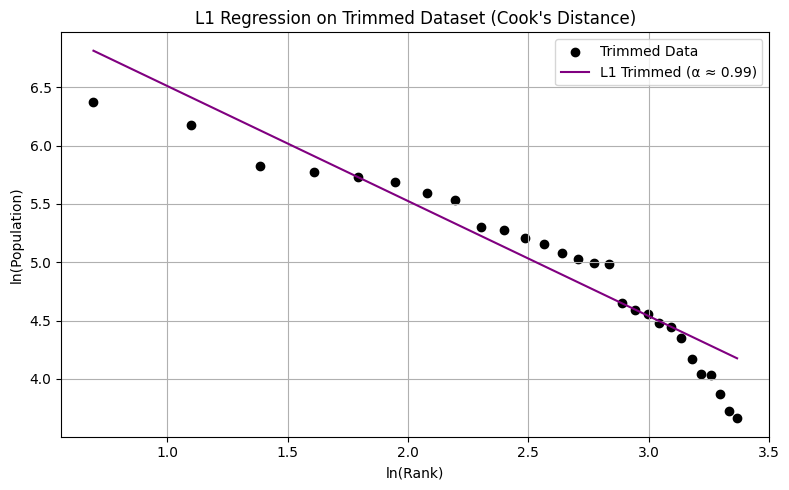

In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
import matplotlib.pyplot as plt

# 1. Load city population data
cities = [
    ("Namangan", 696.5), ("Samarkand", 585.2), ("Andijan", 480.8),
    ("Nukus", 339.2), ("Fergana", 321.8), ("Kokand", 308.1), ("Karshi", 295.6),
    ("Bukhara", 269.5), ("Margilan", 253.5), ("Termiz", 201.6), ("Jizzakh", 195.8),
    ("Angren", 182.4), ("Chirchik", 172.9), ("Navoi", 161.3), ("Urgench", 153.1),
    ("Shakhrisabz", 147.2), ("Almalyk", 146.6), ("Bekabad", 104.3), ("Khiva", 98.8),
    ("Kattaqo'rg'on", 94.9), ("Zarafshan", 88.4), ("Yangiyul", 85.5), ("Gulistan", 77.3),
    ("Kagan", 64.7), ("Kuvasay", 56.8), ("Nurafshan", 56.2), ("Yangier", 48.0),
    ("Akhangaran", 41.4), ("Khanabad", 38.9), ("Shirin", 19.4), ("Gazgan", 9.2)
]

# 2. Create DataFrame and prepare log variables
df = pd.DataFrame(cities, columns=["City", "Population"])
df["Rank"] = df["Population"].rank(ascending=False)
df.sort_values("Rank", inplace=True)
df["log_P"] = np.log(df["Population"])
df["log_R"] = np.log(df["Rank"])
X = sm.add_constant(df["log_R"])

# 3. Fit initial OLS model
ols_model = sm.OLS(df["log_P"], X).fit()

# 4. Calculate Cook's Distance
influence = OLSInfluence(ols_model)
cooks_d = influence.cooks_distance[0]

# 5. Define cutoff and filter out influential points
threshold = 4 / len(df)  # common rule of thumb
df["Cooks_D"] = cooks_d
df_trimmed = df[df["Cooks_D"] < threshold].copy()

# 6. Refit L1 regression on trimmed data
X_trimmed = sm.add_constant(df_trimmed["log_R"])
model_l1_trimmed = sm.QuantReg(df_trimmed["log_P"], X_trimmed).fit(q=0.5)

print(f"ln(P) = {model_l1_trimmed.params[0]:.2f} - {abs(model_l1_trimmed.params[1]):.2f} ln(R)")
print(f"R² = {model_l1_trimmed.prsquared:.2f}, Alpha = {abs(model_l1_trimmed.params[1]):.2f} ± {model_l1_trimmed.bse[1]:.2f}")

# 7. Print results
print(model_l1_trimmed.summary())

# 8. Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_trimmed["log_R"], df_trimmed["log_P"], label="Trimmed Data", color="black")
plt.plot(df_trimmed["log_R"], model_l1_trimmed.predict(X_trimmed), label=f"L1 Trimmed (α ≈ {abs(model_l1_trimmed.params[1]):.2f})", color="purple")
plt.xlabel("ln(Rank)")
plt.ylabel("ln(Population)")
plt.title("L1 Regression on Trimmed Dataset (Cook's Distance)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\96314622.py:29: RuntimeWarning: overflow encountered in exp
  density = (alpha * beta) / (alpha + beta) * (data ** (-alpha - 1)) * np.exp(alpha * mu + (alpha ** 2 * sigma ** 2) / 2) * phi + \
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\96314622.py:30: RuntimeWarning: overflow encountered in exp
  (alpha * beta) / (alpha + beta) * (data ** (beta - 1)) * np.exp(-beta * mu + (beta ** 2 * sigma ** 2) / 2) * phi_comp
C:\Users\VivoBook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


Fitted parameters:
α (left tail): 1.500
β (right tail): 1.500
μ (lognormal mean): 11.919
σ (lognormal std dev): 0.500


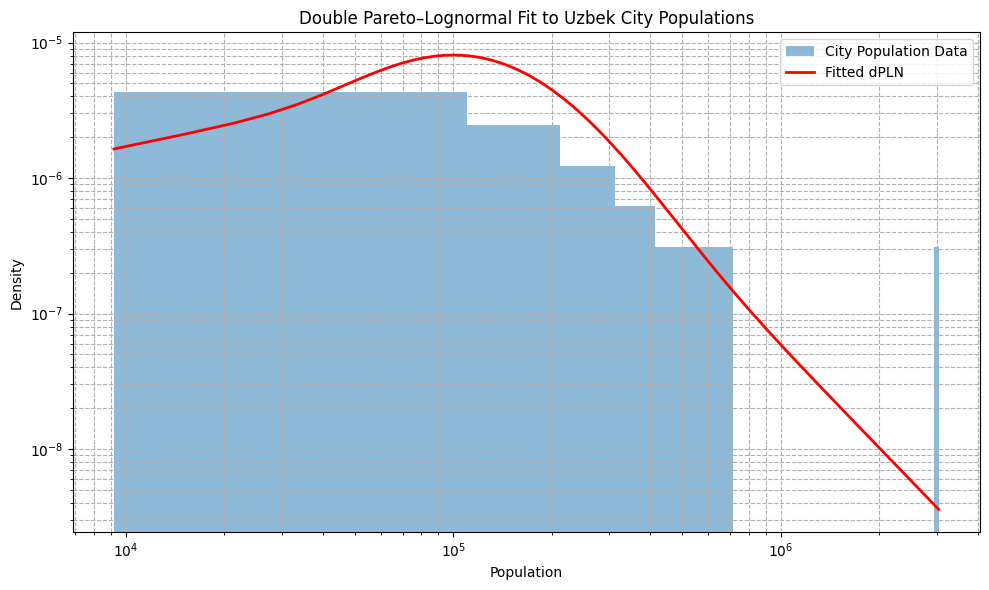

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize


city_pop_df = pd.DataFrame({
    "City": ["Tashkent", "Namangan", "Samarkand", "Andijan", "Nukus", "Fergana", "Kokand",
             "Karshi", "Bukhara", "Margilan", "Termiz", "Jizzakh", "Angren", "Chirchik",
             "Navoi", "Urgench", "Shakhrisabz","Almalyk", "Bekabad", "Khiva", "Kattaqo'rg'on",
             "Zarafshan", "Yangiyul", "Gulistan", "Kagan", "Kuvasay", "Nurafshan", "Yangier", "Akhangaran", "Khanabad", "Shirin", "Gazgan"],
    "Population": [3040800, 696500, 585200, 480800, 339200, 321800, 308100, 295600, 269500, 253500, 201600, 195800, 182400, 172900,
                   161300, 153100, 147200, 146600, 104300, 98800, 94900, 88400, 85500, 77300, 64700, 56800, 56200, 48000, 41400, 38900, 19400, 9200]
})
# --- Step 1: Prepare population data ---
# Replace with your actual DataFrame name and column
pop_data = city_pop_df["Population"].dropna().astype(float).values
pop_data = pop_data[pop_data > 0]  # Remove any zeros or negative values if present

# --- Step 2: Define dPLN log-likelihood ---
def dpln_log_likelihood(params, data):
    alpha, beta, mu, sigma = params
    if alpha <= 0 or beta <= 0 or sigma <= 0:
        return np.inf
    log_x = np.log(data)
    phi = norm.cdf((log_x - mu) / sigma)
    phi_comp = norm.cdf(-(log_x - mu) / sigma)
    density = (alpha * beta) / (alpha + beta) * (data ** (-alpha - 1)) * np.exp(alpha * mu + (alpha ** 2 * sigma ** 2) / 2) * phi + \
              (alpha * beta) / (alpha + beta) * (data ** (beta - 1)) * np.exp(-beta * mu + (beta ** 2 * sigma ** 2) / 2) * phi_comp
    return -np.sum(np.log(density + 1e-10))  # Add small epsilon to avoid log(0)

# --- Step 3: Fit model using MLE ---
initial_params = [1.5, 1.5, np.log(np.median(pop_data)), 0.5]

result = minimize(dpln_log_likelihood, initial_params, args=(pop_data,), method='L-BFGS-B',
                  bounds=[(1e-3, None), (1e-3, None), (None, None), (1e-3, None)])

alpha_fit, beta_fit, mu_fit, sigma_fit = result.x
print("Fitted parameters:")
print(f"α (left tail): {alpha_fit:.3f}")
print(f"β (right tail): {beta_fit:.3f}")
print(f"μ (lognormal mean): {mu_fit:.3f}")
print(f"σ (lognormal std dev): {sigma_fit:.3f}")

# --- Step 4: Define dPLN PDF ---
def dpln_pdf(x, alpha, beta, mu, sigma):
    log_x = np.log(x)
    phi = norm.cdf((log_x - mu) / sigma)
    phi_comp = norm.cdf(-(log_x - mu) / sigma)
    return (alpha * beta) / (alpha + beta) * (x ** (-alpha - 1)) * np.exp(alpha * mu + (alpha ** 2 * sigma ** 2) / 2) * phi + \
           (alpha * beta) / (alpha + beta) * (x ** (beta - 1)) * np.exp(-beta * mu + (beta ** 2 * sigma ** 2) / 2) * phi_comp

# --- Step 5: Plot the result ---
x_vals = np.linspace(min(pop_data), max(pop_data), 500)
pdf_vals = dpln_pdf(x_vals, alpha_fit, beta_fit, mu_fit, sigma_fit)

plt.figure(figsize=(10, 6))
plt.hist(pop_data, bins=30, density=True, alpha=0.5, label="City Population Data")
plt.plot(x_vals, pdf_vals, 'r-', label="Fitted dPLN", linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Population")
plt.ylabel("Density")
plt.title("Double Pareto–Lognormal Fit to Uzbek City Populations")
plt.legend()
plt.grid(True, which='both', linestyle='--')
plt.tight_layout()
plt.show()



C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\2042018846.py:35: RuntimeWarning: overflow encountered in exp
  term1 = (alpha*beta)/(alpha+beta) * (data**(-alpha-1)) * np.exp(alpha*mu + (alpha**2 * sigma**2)/2) * phi
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\2042018846.py:36: RuntimeWarning: overflow encountered in exp
  term2 = (alpha*beta)/(alpha+beta) * (data**(beta-1)) * np.exp(-beta*mu + (beta**2 * sigma**2)/2) * phi_comp
C:\Users\VivoBook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


=== dPLN Fitted Parameters ===
α (left tail): 1.500
β (right tail): 1.500
μ (location): 11.919
σ (scale): 0.500


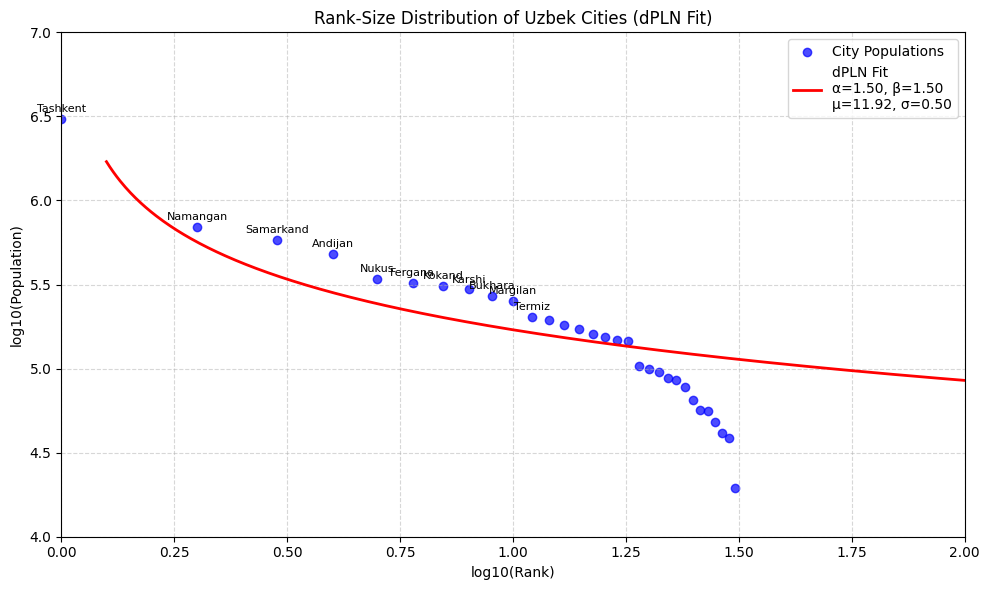

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

# Load city population data
city_pop_df = pd.DataFrame({
    "City": ["Tashkent", "Namangan", "Samarkand", "Andijan", "Nukus", "Fergana", "Kokand",
             "Karshi", "Bukhara", "Margilan", "Termiz", "Jizzakh", "Angren", "Chirchik",
             "Navoi", "Urgench", "Shakhrisabz", "Almalyk", "Bekabad", "Khiva", "Kattaqo'rg'on",
             "Zarafshan", "Yangiyul", "Gulistan", "Kagan", "Kuvasay", "Nurafshan", "Yangier",
             "Akhangaran", "Khanabad", "Shirin", "Gazgan"],
    "Population": [3040800, 696500, 585200, 480800, 339200, 321800, 308100, 295600,
                   269500, 253500, 201600, 195800, 182400, 172900, 161300, 153100,
                   147200, 146600, 104300, 98800, 94900, 88400, 85500, 77300, 64700,
                   56800, 56200, 48000, 41400, 38900, 19400, 9200]
})

# Prepare data
df = city_pop_df.copy()
df['Rank'] = df['Population'].rank(ascending=False)
df = df.sort_values('Rank')
pop_data = df["Population"].values
rank_data = df["Rank"].values

# --- dPLN fitting functions ---
def dpln_log_likelihood(params, data):
    alpha, beta, mu, sigma = params
    if alpha <= 0 or beta <= 0 or sigma <= 0:
        return np.inf  # Penalize invalid parameters
    log_x = np.log(data)
    phi = norm.cdf((log_x - mu)/sigma)
    phi_comp = norm.cdf(-(log_x - mu)/sigma)
    term1 = (alpha*beta)/(alpha+beta) * (data**(-alpha-1)) * np.exp(alpha*mu + (alpha**2 * sigma**2)/2) * phi
    term2 = (alpha*beta)/(alpha+beta) * (data**(beta-1)) * np.exp(-beta*mu + (beta**2 * sigma**2)/2) * phi_comp
    return -np.sum(np.log(term1 + term2 + 1e-10))

# Fit dPLN to population data
initial_params = [1.5, 1.5, np.log(np.median(pop_data)), 0.5]
bounds = [(1e-3, None), (1e-3, None), (None, None), (1e-3, None)]
result = minimize(dpln_log_likelihood, initial_params, args=(pop_data,),
                 method='L-BFGS-B', bounds=bounds)
alpha, beta, mu, sigma = result.x

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Transform data
log_pop = np.log10(pop_data)
log_rank = np.log10(rank_data)

# Plot actual data
plt.scatter(log_rank, log_pop, color='blue', label='City Populations', alpha=0.7)

# Plot dPLN fit (corrected formula)
x_vals = np.linspace(0.1, 2.0, 500)  # Avoid log(0)
dpln_fit = (mu + sigma**2/2)/np.log(10) - np.log10(x_vals)  # Proper log10 scaling
plt.plot(x_vals, dpln_fit, 'r-', linewidth=2,
         label=f'dPLN Fit\nα={alpha:.2f}, β={beta:.2f}\nμ={mu:.2f}, σ={sigma:.2f}')

# Annotate major cities
for _, row in df[df['Population'] > 200000].iterrows():
    plt.annotate(row['City'], (np.log10(row['Rank']), np.log10(row['Population'])),
                 textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)

# Set axis limits
plt.xlim(0.0, 2.0)
plt.ylim(4, 7)

plt.xlabel('log10(Rank)')
plt.ylabel('log10(Population)')
plt.title('Rank-Size Distribution of Uzbek Cities (dPLN Fit)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Print fitted parameters
print("=== dPLN Fitted Parameters ===")
print(f"α (left tail): {alpha:.3f}")
print(f"β (right tail): {beta:.3f}")
print(f"μ (location): {mu:.3f}")
print(f"σ (scale): {sigma:.3f}")

plt.show()

Blom Rank | Quantile | City           | Population | Fitted log(Population)
----------------------------------------------------------------------
        1 |   0.0194 | Gazgan         |       9200 | 9.581510
        2 |   0.0504 | Shirin         |      19400 | 10.048033
        3 |   0.0814 | Khanabad       |      38900 | 10.316971
        4 |   0.1124 | Akhangaran     |      41400 | 10.516351
        5 |   0.1434 | Yangier        |      48000 | 10.679370
        6 |   0.1744 | Nurafshan      |      56200 | 10.819969
        7 |   0.2054 | Kuvasay        |      56800 | 10.945421
        8 |   0.2364 | Kagan          |      64700 | 11.060044
        9 |   0.2674 | Gulistan       |      77300 | 11.166641
       10 |   0.2984 | Yangiyul       |      85500 | 11.267157
       11 |   0.3295 | Zarafshan      |      88400 | 11.363014
       12 |   0.3605 | Kattaqo'rg'on  |      94900 | 11.455301
       13 |   0.3915 | Khiva          |      98800 | 11.544889
       14 |   0.4225 | Bekabad     

C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\1542519531.py:30: RuntimeWarning: overflow encountered in exp
  (data ** (-alpha - 1)) * np.exp(alpha * mu + (alpha**2 * sigma**2) / 2) * phi +
C:\Users\VivoBook\AppData\Local\Temp\ipykernel_34788\1542519531.py:31: RuntimeWarning: overflow encountered in exp
  (data ** (beta - 1)) * np.exp(-beta * mu + (beta**2 * sigma**2) / 2) * phi_comp
C:\Users\VivoBook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


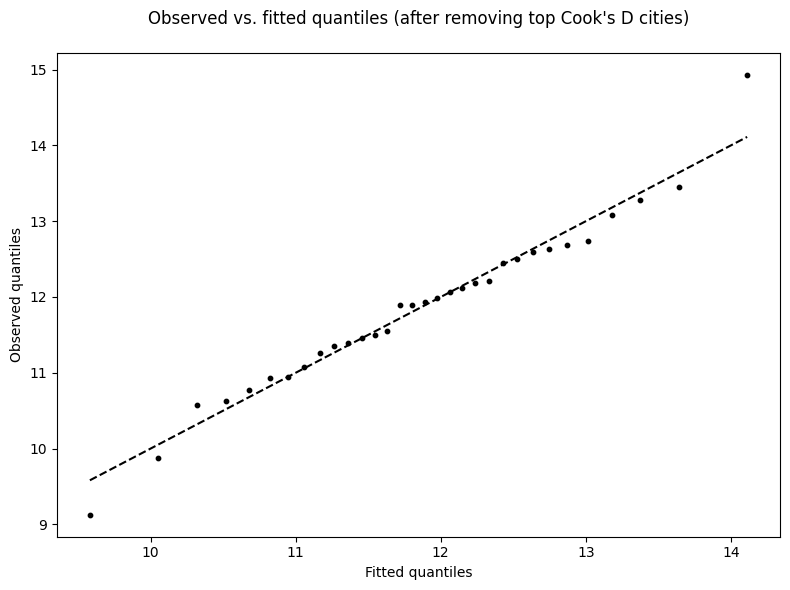

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

# 1. Uzbek City Population Data (removed: Gazgan, Namangan, Shirin, Samarkand, Almalyk)
city_pop_df = pd.DataFrame({
    "City": ["Tashkent", "Namangan", "Samarkand", "Andijan", "Nukus", "Fergana", "Kokand",
             "Karshi", "Bukhara", "Margilan", "Termiz", "Jizzakh", "Angren", "Chirchik",
             "Navoi", "Urgench", "Shakhrisabz","Almalyk", "Bekabad", "Khiva", "Kattaqo'rg'on",
             "Zarafshan", "Yangiyul", "Gulistan", "Kagan", "Kuvasay", "Nurafshan", "Yangier",
             "Akhangaran", "Khanabad", "Shirin", "Gazgan"],
    "Population": [3040800, 696500, 585200, 480800, 339200, 321800, 308100, 295600, 269500, 253500,
                   201600, 195800, 182400, 172900, 161300, 153100, 147200, 146600, 104300, 98800,
                   94900, 88400, 85500, 77300, 64700, 56800, 56200, 48000, 41400, 38900, 19400, 9200]
})
pop_data = city_pop_df["Population"].astype(float).values
pop_data = pop_data[pop_data > 0]

# --- 2. dPLN Log-Likelihood ---
def dpln_log_likelihood(params, data):
    alpha, beta, mu, sigma = params
    if alpha <= 0 or beta <= 0 or sigma <= 0:
        return np.inf
    log_x = np.log(data)
    phi = norm.cdf((log_x - mu) / sigma)
    phi_comp = norm.cdf(-(log_x - mu) / sigma)
    density = ((alpha * beta) / (alpha + beta)) * (
        (data ** (-alpha - 1)) * np.exp(alpha * mu + (alpha**2 * sigma**2) / 2) * phi +
        (data ** (beta - 1)) * np.exp(-beta * mu + (beta**2 * sigma**2) / 2) * phi_comp
    )
    return -np.sum(np.log(density + 1e-10))

# --- 3. Fit Model using MLE (with data-driven initial guesses) ---
log_data = np.log(pop_data)
mu_init = np.mean(log_data)
sigma_init = np.std(log_data)
alpha_init = 1 + 1 / (np.mean(np.log(pop_data / np.min(pop_data))))
beta_init = alpha_init

initial_params = [alpha_init, beta_init, mu_init, sigma_init]
bounds = [(1e-5, None), (1e-5, None), (None, None), (1e-5, None)]

result = minimize(dpln_log_likelihood, initial_params, args=(pop_data,), method='L-BFGS-B', bounds=bounds)
alpha_fit, beta_fit, mu_fit, sigma_fit = result.x


# --- 4. Q-Q Plot Data ---
log_obs_sorted = np.sort(np.log(pop_data))
quantiles = np.linspace(0.01, 0.99, len(pop_data))
n = len(pop_data)
quantiles = (np.arange(1, n + 1) - 0.375) / (n + 0.25)  # Blom's formula
log_fit_sorted = norm.ppf(quantiles, loc=mu_fit, scale=sigma_fit)


# Create DataFrame with log(population) and city names
city_pop_df['log_population'] = np.log(city_pop_df['Population'])

# Sort by log(population) to match Q-Q plot order (Blom’s order)
blom_ordered = city_pop_df.sort_values(by='log_population').reset_index(drop=True)

# Compute Blom's quantiles
n = len(blom_ordered)
quantiles = (np.arange(1, n + 1) - 0.375) / (n + 0.25)

# Compute fitted log-population quantiles using normal distribution
from scipy.stats import norm
log_fit_sorted = norm.ppf(quantiles, loc=mu_fit, scale=sigma_fit)

# Add fitted log-population to the DataFrame
blom_ordered['Blom_quantile'] = quantiles
blom_ordered['Fitted_log_Pop'] = log_fit_sorted

# Print table
print("Blom Rank | Quantile | City           | Population | Fitted log(Population)")
print("-" * 70)
for i, row in blom_ordered.iterrows():
    print(f"{i+1:9} | {row.Blom_quantile:8.4f} | {row.City:14} | {int(row.Population):10} | {row.Fitted_log_Pop:.6f}")


# Step 1: Add log(population) to the DataFrame
city_pop_df['log_population'] = np.log(city_pop_df['Population'])

# Step 2: Sort cities by log(population) to get the same order as log_obs_sorted
obs_ordered = city_pop_df.sort_values(by='log_population').reset_index(drop=True)

# Step 3: Print observed log-populations (log_obs_sorted)
print("Rank | City           | Population | Observed log(Population)")
print("-" * 60)
for i, row in obs_ordered.iterrows():
    print(f"{i+1:4} | {row.City:14} | {int(row.Population):10} | {row.log_population:.6f}")



# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(log_fit_sorted, log_obs_sorted, color='black', s=10)
ax.plot(log_fit_sorted, log_fit_sorted, 'k--')
ax.set_title("Observed vs. fitted quantiles (after removing top Cook's D cities)\n")
ax.set_xlabel("Fitted quantiles")
ax.set_ylabel("Observed quantiles")

plt.tight_layout()
plt.show()

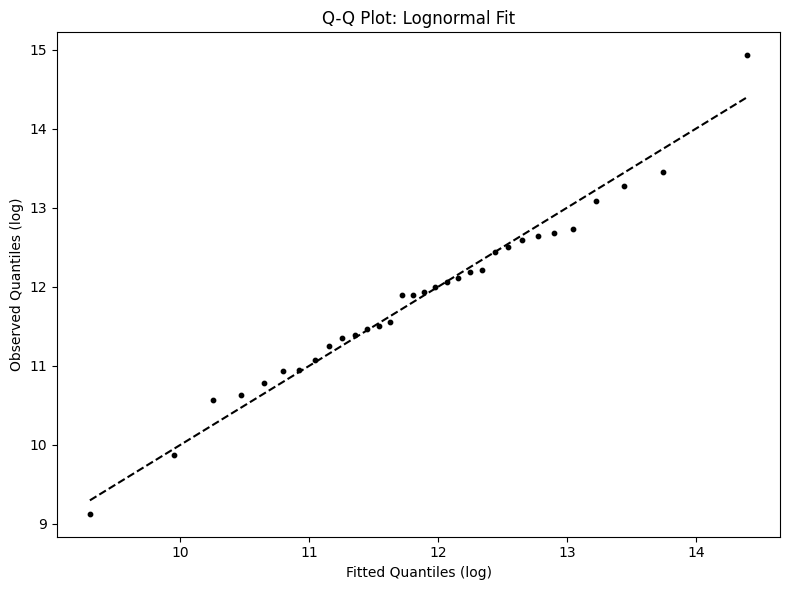

In [13]:
from scipy.stats import lognorm

# Fit lognormal (scipy uses shape = sigma, scale = exp(mu))
shape, loc, scale = lognorm.fit(pop_data, floc=0)

# Generate quantiles
log_obs_sorted = np.sort(np.log(pop_data))
quantiles = np.linspace(0.01, 0.99, len(pop_data))
log_fit_sorted = lognorm.ppf(quantiles, s=shape, loc=loc, scale=scale)
log_fit_sorted = np.log(log_fit_sorted)  # log for QQ plot

# Plot
plt.figure(figsize=(8,6))
plt.scatter(log_fit_sorted, log_obs_sorted, color='black', s=10)
plt.plot(log_fit_sorted, log_fit_sorted, 'k--')
plt.title("Q-Q Plot: Lognormal Fit")
plt.xlabel("Fitted Quantiles (log)")
plt.ylabel("Observed Quantiles (log)")
plt.tight_layout()
plt.show()
